In [1]:
import pandas as pd

veri_sozlugu = {
    'Hafta': [1, 2, 3, 4, 5, 6],
    'Satis_Fiyati': [300, 400, 500, 600, 700, 800],
    'Satis_Adedi': [100, 85, 60, 40, 20, 5],
    'Urun_Maliyeti': [200, 200, 200, 200, 200, 200]
}

df = pd.DataFrame(veri_sozlugu)
df

,Hafta,Satis_Fiyati,Satis_Adedi,Urun_Maliyeti
0,1,300,100,200
1,2,400,85,200
2,3,500,60,200
3,4,600,40,200
4,5,700,20,200
5,6,800,5,200


In [2]:
!pip install scikit-learn matplotlib scipy

Algoritmanın bulduğu formül: Satış Adedi = (-0.1971 * Fiyat) + 160.10


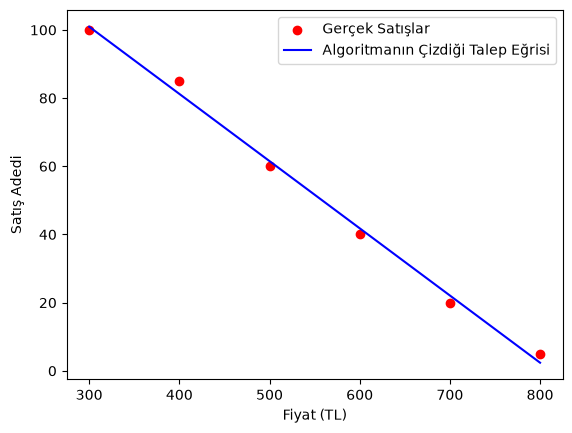

In [3]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = df['Satis_Fiyati'].values.reshape(-1, 1)
y = df['Satis_Adedi'].values

model = LinearRegression()
model.fit(X, y)

a_katsayisi = model.coef_[0]
b_sabiti = model.intercept_

print(f"Algoritmanın bulduğu formül: Satış Adedi = ({a_katsayisi:.4f} * Fiyat) + {b_sabiti:.2f}")

plt.scatter(df['Satis_Fiyati'], df['Satis_Adedi'], color='red', label='Gerçek Satışlar')
plt.plot(df['Satis_Fiyati'], model.predict(X), color='blue', label='Algoritmanın Çizdiği Talep Eğrisi')
plt.xlabel('Fiyat (TL)')
plt.ylabel('Satış Adedi')
plt.legend()
plt.show()

In [4]:
import numpy as np
from scipy.optimize import minimize_scalar

maliyet = 200 

def negatif_kar_fonksiyonu(fiyat):
    tahmini_satis_adedi = (-0.1943 * fiyat) + 162.38
    
    if tahmini_satis_adedi < 0:
        return 0
        
    toplam_kar = tahmini_satis_adedi * (fiyat - maliyet)
    return -toplam_kar 

sonuc = minimize_scalar(negatif_kar_fonksiyonu, bounds=(200, 1000), method='bounded')

optimal_fiyat = sonuc.x
maksimum_kar = -sonuc.fun
tahmini_adet = (-0.1943 * optimal_fiyat) + 162.38

print(f"🎯 Algoritmanın Bulduğu En İdeal Satış Fiyatı: {optimal_fiyat:.2f} TL")
print(f"📦 Bu fiyattan satılacak tahmini adet: {int(tahmini_adet)} tane")
print(f"💰 Elde edilecek maksimum toplam kâr: {maksimum_kar:.2f} TL")

🎯 Algoritmanın Bulduğu En İdeal Satış Fiyatı: 517.86 TL
📦 Bu fiyattan satılacak tahmini adet: 61 tane
💰 Elde edilecek maksimum toplam kâr: 19630.97 TL


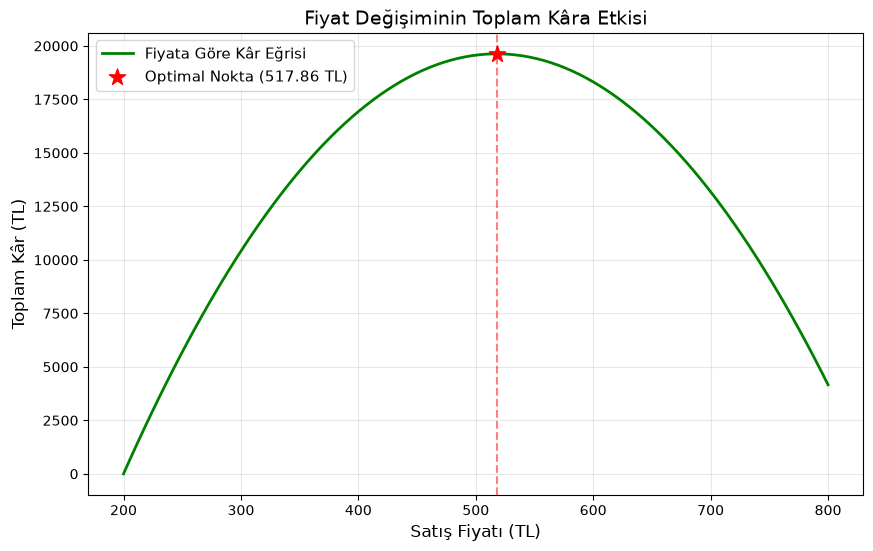

In [5]:
import numpy as np
import matplotlib.pyplot as plt

fiyat_araligi = np.linspace(200, 800, 100)
kar_listesi = []

for f in fiyat_araligi:
    tahmini_adet = (-0.1943 * f) + 162.38

    if tahmini_adet < 0:
        tahmini_adet = 0
    kar = tahmini_adet * (f - 200)
    kar_listesi.append(kar)

plt.figure(figsize=(10, 6))
plt.plot(fiyat_araligi, kar_listesi, color='green', linewidth=2, label='Fiyata Göre Kâr Eğrisi')

plt.scatter(517.86, 19630.97, color='red', s=150, marker='*', zorder=5, label='Optimal Nokta (517.86 TL)')

plt.title('Fiyat Değişiminin Toplam Kâra Etkisi', fontsize=14)
plt.xlabel('Satış Fiyatı (TL)', fontsize=12)
plt.ylabel('Toplam Kâr (TL)', fontsize=12)
plt.axvline(x=517.86, color='red', linestyle='--', alpha=0.5) # Dik çizgi
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
!pip install streamlit

In [7]:
%%writefile arayuz.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import minimize_scalar

st.set_page_config(page_title="Dinamik Fiyat Optimizasyonu", layout="wide")
st.title("📊 Yapay Zekâ Destekli Dinamik Fiyat Optimizasyon Simülatörü")
st.markdown("Bu uygulama, geçmiş satış verilerinden talep eğrisini öğrenir ve kârı maksimum yapan fiyatı hesaplar.")

veri_sozlugu = {
    'Satis_Fiyati': [300, 400, 500, 600, 700, 800],
    'Satis_Adedi': [100, 85, 60, 40, 20, 5]
}
df = pd.DataFrame(veri_sozlugu)

st.sidebar.header("⚙️ Ürün ve Maliyet Ayarları")
maliyet = st.sidebar.number_input("Ürün Birim Maliyeti (TL):", min_value=10, max_value=1000, value=200, step=10)
kullanici_fiyati = st.sidebar.slider("Manuel Fiyat Test Et (TL):", min_value=200, max_value=800, value=400, step=10)

X = df['Satis_Fiyati'].values.reshape(-1, 1)
y = df['Satis_Adedi'].values
model = LinearRegression()
model.fit(X, y)
a_katsayisi = model.coef_[0]
b_sabiti = model.intercept_

def negatif_kar_fonksiyonu(fiyat):
    tahmini_satis_adedi = (a_katsayisi * fiyat) + b_sabiti
    if tahmini_satis_adedi < 0: return 0
    toplam_kar = tahmini_satis_adedi * (fiyat - maliyet)
    return -toplam_kar

sonuc = minimize_scalar(negatif_kar_fonksiyonu, bounds=(maliyet, 1000), method='bounded')
optimal_fiyat = sonuc.x
maksimum_kar = -sonuc.fun
optimal_adet = (a_katsayisi * optimal_fiyat) + b_sabiti

manuel_adet = (a_katsayisi * kullanici_fiyati) + b_sabiti
if manuel_adet < 0: manuel_adet = 0
manuel_kar = manuel_adet * (kullanici_fiyati - maliyet)

col1, col2, col3 = st.columns(3)
with col1:
    st.metric(label="🎯 Yapay Zekânın Önerdiği Optimal Fiyat", value=f"{optimal_fiyat:.2f} TL")
with col2:
    st.metric(label="📦 Tahmini Satış Adedi", value=f"{int(optimal_adet)} Adet")
with col3:
    st.metric(label="💰 Hedeflenen Maksimum Kâr", value=f"{maksimum_kar:,.2f} TL")

st.divider()

st.subheader("🔍 Sizin Seçtiğiniz Fiyatın Analizi")
st.write(f"Fiyatı elle **{kullanici_fiyati} TL** yaptığınızda; tahmini **{int(manuel_adet)} adet** satarsınız ve toplam kârınız **{manuel_kar:,.2f} TL** olur.")
st.write(f"Yapay zekanın optimal fiyatına geçerek kârınızı **{maksimum_kar - manuel_kar:,.2f} TL** artırabilirsiniz!")

fiyat_araligi = np.linspace(maliyet, 800, 100)
kar_listesi = [(lambda f: max(0, (a_katsayisi * f) + b_sabiti) * (f - maliyet))(f) for f in fiyat_araligi]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fiyat_araligi, kar_listesi, color='green', label='Kâr Eğrisi')
ax.scatter(optimal_fiyat, maksimum_kar, color='red', s=100, marker='*', zorder=5, label=f'Optimal Nokta ({optimal_fiyat:.1f} TL)')
ax.scatter(kullanici_fiyati, manuel_kar, color='blue', s=80, marker='o', zorder=5, label=f'Sizin Fiyatınız ({kullanici_fiyati} TL)')
ax.set_xlabel("Fiyat (TL)")
ax.set_ylabel("Toplam Kâr (TL)")
ax.legend()
st.pyplot(fig)

Writing arayuz.py
